In [1]:
import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from utils import *
from genData import *
from plot import *
from model.unet import *

# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available. No GPU found.")

# Configuration
det = 'H1L1'
f0 = 500
size = (512, 64)
Tsft = 14400
train_level = 22
batch_size = 8

# Model version
version = f'H1L1_a1b1_{f0}Hz_D{train_level}-{train_level}_T10_f512xTsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x64_MSELoss_dropout0'

# Load validation data (targets and masks)
filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_seed4.npz'
val_data = np.load(filename, allow_pickle=True)
targets = val_data['clean_image']
masks = new_mask(normalize(targets))  # Assuming new_mask and normalize are defined in utils

# Load model
model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
best_val_model = torch.load(f"../trained_model/{f0}Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False)
model.load_state_dict(best_val_model)

25-08-29 18:06:23.421 pyfstat INFO    : Running PyFstat version 2.1.0


/home/damoncht/.conda/envs/ml/lib/python3.9/site-packages/pyfstat/core.py:12: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


GPU Name: Tesla P40


<All keys matched successfully>

In [2]:
class Attention_UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, latent_channels=64, dropout_prob=0):
        super(Attention_UNet, self).__init__()
        
        self.Maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.Upsample = nn.Upsample(scale_factor=2)

        # Encoder
        self.encoder = nn.ModuleList([
            conv_block(in_channels=in_channels, out_channels=latent_channels),
            conv_block(in_channels=latent_channels, out_channels=latent_channels*2),
            conv_block(in_channels=latent_channels*2, out_channels=latent_channels*4),
            conv_block(in_channels=latent_channels*4, out_channels=latent_channels*8)
        ])

        # Bottleneck
        self.bottleneck = nn.Sequential(
            conv_block(in_channels=latent_channels*8, out_channels=latent_channels*16),
            nn.Dropout2d(p=dropout_prob) if dropout_prob > 0 else nn.Identity()
        )
        
        # Decoder
        self.decoder = nn.ModuleList([
            conv_block(in_channels=latent_channels*16, out_channels=latent_channels*8),
            conv_block(in_channels=latent_channels*8, out_channels=latent_channels*4),
            conv_block(in_channels=latent_channels*4, out_channels=latent_channels*2),
            conv_block(in_channels=latent_channels*2, out_channels=latent_channels)
        ])
        
        self.upsample_layer = nn.ModuleList([
            up_conv(in_channels=latent_channels*16, out_channels=latent_channels*8),
            up_conv(in_channels=latent_channels*8, out_channels=latent_channels*4),
            up_conv(in_channels=latent_channels*4, out_channels=latent_channels*2),
            up_conv(in_channels=latent_channels*2, out_channels=latent_channels)
        ])
        
        self.attention_layer = nn.ModuleList([
            Attention_block(F_g=latent_channels*8, F_l=latent_channels*8, F_int=latent_channels*4),
            Attention_block(F_g=latent_channels*4, F_l=latent_channels*4, F_int=latent_channels*2),
            Attention_block(F_g=latent_channels*2, F_l=latent_channels*2, F_int=latent_channels),
            Attention_block(F_g=latent_channels, F_l=latent_channels, F_int=latent_channels//2)
        ])

        self.output_layer = nn.Sequential(
            nn.Conv2d(latent_channels, out_channels, kernel_size=1, stride=1, padding=0),
            nn.Tanh()
        )

        # Storage for intermediate outputs
        self.intermediate_outputs = {
            'encoder': [],
            'skip_connections': [],
            'attention': [],
            'decoder': [],
            'bottleneck': None
        }

    def forward(self, x, save_intermediates=False):

        # Encoder
        skip_connections = []
        for i, conv in enumerate(self.encoder):
            x = conv(x)
            if save_intermediates:
                self.intermediate_outputs['encoder'].append(x.clone())
                
            skip_connections.append(x)
            if save_intermediates:
                self.intermediate_outputs['skip_connections'] = [s.clone() for s in skip_connections]
            x = self.Maxpool(x)
        # Bottleneck
        x = self.bottleneck(x)
        if save_intermediates:
            self.intermediate_outputs['bottleneck'] = x.clone()

        # Decoder
        for i, (up, att, conv) in enumerate(zip(self.upsample_layer, self.attention_layer, self.decoder)):
            x = up(x)
            ag_x = att(g=x, x=skip_connections[-(i+1)])
            if save_intermediates:
                self.intermediate_outputs['attention'].append(ag_x.clone())
            x = torch.cat((ag_x, x), dim=1)
            x = conv(x)
            if save_intermediates:
                self.intermediate_outputs['decoder'].append(x.clone())

        x = self.output_layer(x)
        return x

    def get_intermediate_outputs(self):
        return self.intermediate_outputs

In [7]:
max_train_levels = [20]
duty_factor = 1.0 
model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
best_val_model = torch.load(f"../trained_model/{f0}Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False)
model.load_state_dict(best_val_model)
# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    
    data = noise + targets
    data = normalize(data)
    data = apply_duty_factor(data, duty_factor, size)  # Apply duty factor
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)
    
    # Compute predictions
    predictions, inputs, ground_truth = [], [], []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images, save_intermediates=True)
            predictions.append(outputs.cpu().numpy())
            break 
    predictions = np.concatenate(predictions, axis=0)

Processing Sn=20:   0%|          | 0/125 [00:00<?, ?it/s]


Feature maps dictionary shapes:
input: (512, 64)
encoder: [(512, 64), (256, 32), (128, 16), (64, 8)]
skip_connections: [(512, 64), (256, 32), (128, 16), (64, 8)]
bottleneck: (32, 4)
attention: [(64, 8), (128, 16), (256, 32), (512, 64)]
decoder: [(64, 8), (128, 16), (256, 32), (512, 64)]
output: (512, 64)
(512, 64)
(256, 32)
(128, 16)
(64, 8)
(64, 8)
(128, 16)
(256, 32)
(512, 64)


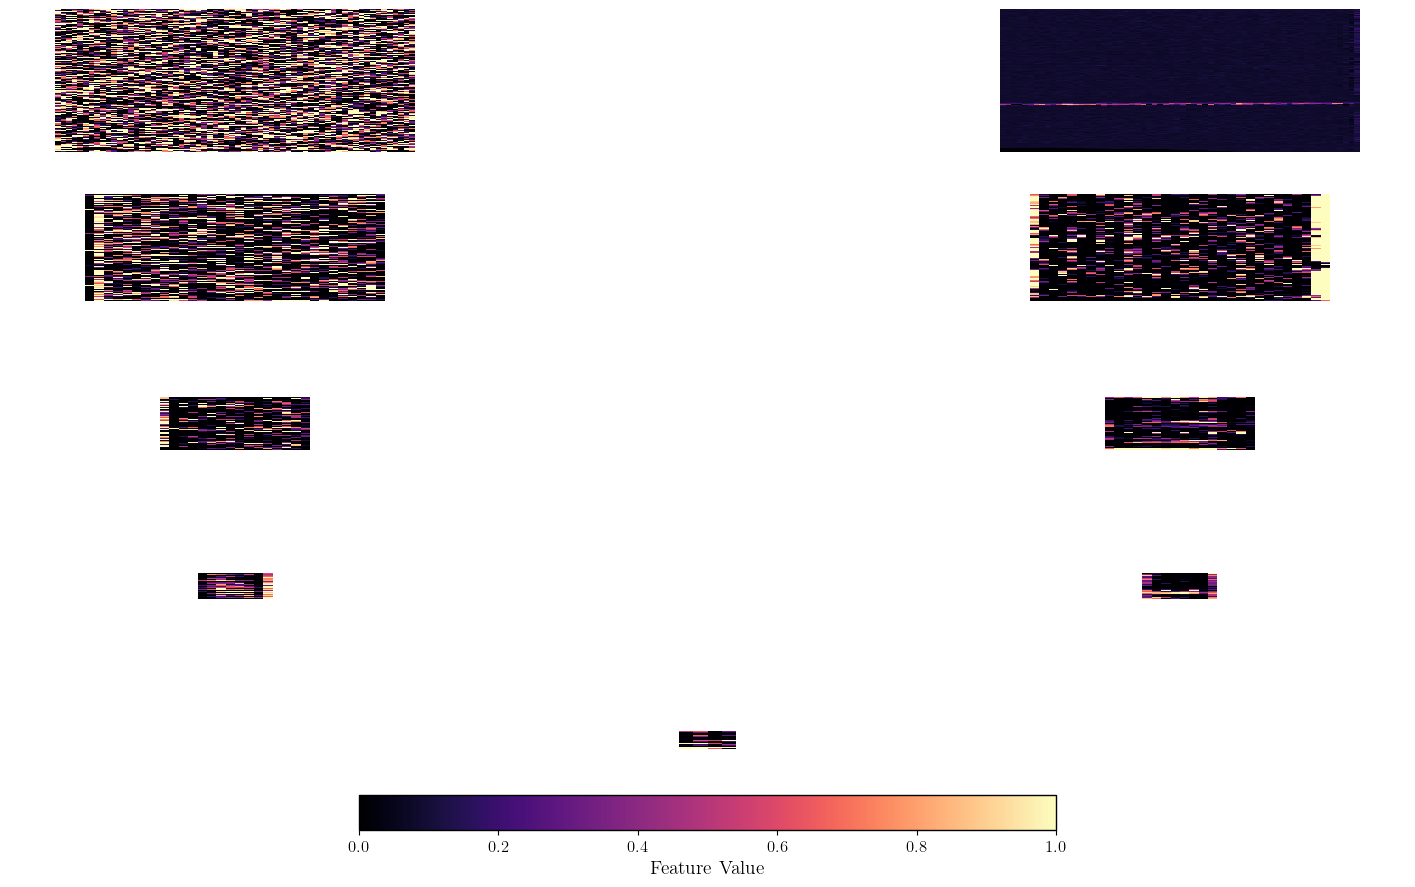

(<Figure size 1800x1200 with 16 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import ConnectionPatch
import numpy as np

def plot_unet_spectrograms(title, encoder_maps, decoder_maps, bottleneck_map, subtitles):
    """
    Plots nine feature maps (four encoder, four decoder, one bottleneck) in a U-shaped figure.
    Encoder maps descend on left, decoder maps ascend on right, bottleneck is centered in
    bottom middle. Maps are centered by midpoint, with axis ranges reflecting actual dimensions.
    Zeroed regions are NaN and grey. Includes arrows for U-Net flow (encoder to bottleneck to
    decoder, encoder to decoder with 'Attention Gate' labels). White backgrounds, shared colorbar.

    Parameters:
    - title (str): Figure title.
    - encoder_maps (list of ndarray): Four 2D arrays (encoder feature maps).
      Shape: (height, width).
    - decoder_maps (list of ndarray): Four 2D arrays (decoder feature maps).
      Shape: (height, width).
    - bottleneck_map (ndarray): 2D array (bottleneck feature map).
      Shape: (height, width).
    - subtitles (list of str): Nine subtitles (four encoder, four decoder, one bottleneck).

    Returns:
    - fig (Figure): Matplotlib figure object.
    - axs (Axes): Array of axes objects.
    """
    # Validate inputs
    if len(encoder_maps) != 4 or len(decoder_maps) != 4 or len(subtitles) != 9:
        raise ValueError("encoder_maps and decoder_maps must have 4 elements each, subtitles must have 9")
    if not isinstance(bottleneck_map, np.ndarray) or bottleneck_map.ndim != 2:
        raise ValueError("bottleneck_map must be a 2D numpy array")

    # Combine maps
    feature_maps = encoder_maps + decoder_maps + [bottleneck_map]

    # Debugging: Print shapes and statistics
    #print(f"Feature map shapes: {[data.shape for data in feature_maps]}")
    # for i, data in enumerate(feature_maps):
    #     valid_data = data[~np.isnan(data)]
    #     if valid_data.size == 0:
    #         print(f"Warning: {subtitles[i]} is all zeros or NaNs")
    #     else:
    #         print(f"{subtitles[i]} stats: min={valid_data.min():.4f}, max={valid_data.max():.4f}, mean={valid_data.mean():.4f}")

    # Create figure with 4x3 grid
    fig, axs = plt.subplots(5, 3, figsize=(18, 12), sharex=False, sharey=False,
                            gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
    fig.patch.set_facecolor('white')

    # Process feature maps
    processed_powers = []
    for i, data in enumerate(feature_maps):
        zero_columns = np.all(data == 0, axis=0)
        #print(f"Number of zero columns in {subtitles[i]}: {np.sum(zero_columns)}")
        power = data.copy()
        power[power == 0] = np.nan
        masked_power = np.ma.masked_invalid(power)
        processed_powers.append(masked_power)
        nan_columns = np.any(np.isnan(power), axis=0)
        #print(f"Number of NaN columns in {subtitles[i]}: {np.sum(nan_columns)}")

    # Compute vmin and vmax
    non_empty_powers = [power for power in processed_powers if power.compressed().size > 0]
    if not non_empty_powers:
        raise ValueError("All feature map data is zero or NaN")
    vmin = min(np.min(power.compressed()) for power in non_empty_powers)
    vmax = max(np.max(power.compressed()) for power in non_empty_powers)
    #print(f"vmin: {vmin}, vmax: {vmax}")
    vmin, vmax = 0, 1  # Normalize
    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    # Colormap
    cmap = plt.get_cmap('magma').copy()
    cmap.set_bad(color='grey')

    # Max dimensions for consistent axes
    max_width = max(data.shape[1] for data in feature_maps)
    max_height = max(data.shape[0] for data in feature_maps)
    x_center = max_width / 2

    # Plot feature maps
    # Encoder (left column, descending)
    for i in range(4):
        ax = axs[i, 0]
        masked_power = processed_powers[i]
        height, width = masked_power.shape
        print(masked_power.shape)
        if i == 0:
            x_start = x_center - width / 2.5
            x_end = x_center + width / 2.5
        else:
            x_start = x_center - width / 1.5
            x_end = x_center + width / 1.5
            
        x_indices = np.linspace(x_start, x_end, width + 1)
        
        if i == 0:
            y_indices = np.linspace(0, height, height + 1)
        else:
            y_indices = np.linspace(0, 1.5*height, height + 1)
        
        c = ax.pcolormesh(
            x_indices,
            y_indices,
            masked_power,
            cmap=cmap,
            norm=norm,
            shading='auto',
            edgecolors='none'
        )
        ax.set_xlim(0, max_width)
        ax.set_ylim(0, max_height)
        #ax.set_title(subtitles[i], fontsize=16, loc='right', y=0, color='black')
        ax.set_facecolor('white')
        for spine in ax.spines.values():
            spine.set_visible(False)
        #if i == 1:
        #    ax.set_ylabel(r'Feature Index', fontsize=14, color='black')
        #if i == 3:
        #    ax.set_xlabel(r'Time Index', fontsize=14, color='black')
        #ax.tick_params(axis='both', labelsize=12, colors='black')
        ax.set_xticks([])
        ax.set_xticklabels([])

        ax.set_yticks([])
        ax.set_yticklabels([])

    # Decoder (right column, ascending, levels 4-2 at axs[2:0:-1, 2])
    for i in range(4):
        ax = axs[3-i, 2]
        masked_power = processed_powers[4 + i]
        height, width = masked_power.shape
        print(masked_power.shape)
        if i == 3:
            x_start = x_center - width / 2.5
            x_end = x_center + width / 2.5
        else:
            x_start = x_center - width / 1.5
            x_end = x_center + width / 1.5
        x_indices = np.linspace(x_start, x_end, width + 1)
        if i == 3:
            y_indices = np.linspace(0, height, height + 1)
        else:
            y_indices = np.linspace(0, 1.5*height, height + 1)
        c = ax.pcolormesh(
            x_indices,
            y_indices,
            masked_power,
            cmap=cmap,
            norm=norm,
            shading='auto',
            edgecolors='none'
        )
        ax.set_xlim(0, max_width)
        ax.set_ylim(0, max_height)
        #ax.set_title(subtitles[4 + i], fontsize=16, loc='right', y=0, color='black')
        ax.set_facecolor('white')
        for spine in ax.spines.values():
            spine.set_visible(False)
        #if i == 1:  # Second from top
        #    ax.set_ylabel(r'Feature Index', fontsize=14, color='black')
        #if i == 2:
        #    ax.set_xlabel(r'Time Index', fontsize=14, color='black')
        #ax.tick_params(axis='both', labelsize=12, colors='black')
        ax.set_yticks([])
        ax.set_yticklabels([])
        ax.set_xticks([])
        ax.set_xticklabels([])


    # Bottleneck (bottom middle, axs[3, 1])
    ax = axs[4, 1]
    masked_power = processed_powers[8]
    height, width = masked_power.shape
    x_start = x_center - width 
    x_end = x_center + width 
    x_indices = np.linspace(x_start, x_end, width + 1)
    y_indices = np.linspace(0, 2*height, height + 1)
    c = ax.pcolormesh(
        x_indices,
        y_indices,
        masked_power,
        cmap=cmap,
        norm=norm,
        shading='auto',
        edgecolors='none'
    )
    ax.set_xlim(0, max_width)
    ax.set_ylim(0, max_height)
    #ax.set_title(subtitles[8], fontsize=16, loc='right', y=0, color='black')
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(False)
    #ax.set_xlabel(r'Time Index', fontsize=14, color='black')
    #ax.tick_params(axis='both', labelsize=12, colors='black')
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_xticklabels([])

    # Hide unused axes
    for ax in [axs[0, 1], axs[1, 1], axs[2, 1], axs[3, 1], axs[4, 0], axs[4, 2]]:
        ax.set_visible(False)

#     # Add arrows for U-Net flow
#     # Encoder level 4 to bottleneck (axs[3, 0] to axs[3, 1])
#     xyA = (max_width, 0)  # Bottom right of encoder level 4
#     xyB = (0, max_height)  # Top left of bottleneck
#     coordsA = "data"
#     coordsB = "data"
#     con = ConnectionPatch(
#         xyA, xyB, coordsA, coordsB,
#         axesA=axs[3, 0], axesB=axs[3, 1],
#         arrowstyle="->", shrinkA=5, shrinkB=5,
#         mutation_scale=20, fc="black", ec="black"
#     )
#     fig.add_artist(con)

#     # Bottleneck to decoder level 4 (axs[3, 1] to axs[2, 2])
#     xyA = (max_width, max_height)  # Top right of bottleneck
#     xyB = (0, 0)  # Bottom left of decoder level 4
#     con = ConnectionPatch(
#         xyA, xyB, coordsA, coordsB,
#         axesA=axs[3, 1], axesB=axs[2, 2],
#         arrowstyle="->", shrinkA=5, shrinkB=5,
#         mutation_scale=20, fc="black", ec="black"
#     )
#     fig.add_artist(con)

#     # Skip connections with Attention Gate labels
#     for i in range(4):
#         enc_ax = axs[i, 0]
#         if i == 0:
#             dec_ax = axs[0, 2]  # Decoder level 1
#         else:
#             dec_ax = axs[3-i, 2]  # Decoder levels 2-4
#         # Arrow from encoder right to decoder left
#         xyA = (max_width, max_height/2)  # Right center of encoder
#         xyB = (0, max_height/2)  # Left center of decoder
#         con = ConnectionPatch(
#             xyA, xyB, coordsA, coordsB,
#             axesA=enc_ax, axesB=dec_ax,
#             arrowstyle="->", shrinkA=5, shrinkB=5,
#             mutation_scale=20, fc="black", ec="black"
#         )
#         fig.add_artist(con)
#         # Add "Attention Gate" label near arrow start
#         # Transform to figure coordinates for label placement
#         trans = enc_ax.transData + fig.transFigure.inverted()
#         x_fig, y_fig = trans.transform((max_width - 10, max_height/2))
#         fig.text(x_fig - 0.05, y_fig, "Attention Gate", fontsize=12, color='black',
#                  ha='right', va='center', rotation=0)

    # Add colorbar
    cbar = fig.colorbar(c, ax=axs, orientation='horizontal', pad=0.05, shrink=0.5)
    cbar.set_label(r'Feature Value', fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.set_facecolor('white')
    #fig.suptitle(title, fontsize=18, color='black')
    plt.show()
    return fig, axs

# Load feature_maps_dict
feature_maps_dict = np.load('intermediate_outputs/feature_maps_idx_12_first_channel.npy', allow_pickle=True).item()

# Print shapes
print("Feature maps dictionary shapes:")
for key, value in feature_maps_dict.items():
    if isinstance(value, list):
        print(f"{key}: {[v.shape for v in value]}")
    else:
        print(f"{key}: {value.shape}")

# Plot
plot_unet_spectrograms(
    title="U-Net Feature Maps with Bottleneck and Attention Gates",
    encoder_maps=feature_maps_dict['encoder'],
    decoder_maps=feature_maps_dict['decoder'],
    bottleneck_map=feature_maps_dict['bottleneck'],
    subtitles=[
        "Encoder Level 1", "Encoder Level 2", "Encoder Level 3", "Encoder Level 4",
        "Decoder Level 4", "Decoder Level 3", "Decoder Level 2", "Decoder Level 1",
        "Bottleneck"
    ]
)

In [72]:
feature_maps_dict['encoder'][3].shape

(64, 8)

In [73]:
feature_maps_dict['decoder'][-4].shape

(64, 8)

In [8]:
feature_maps_dict['encoder'][3].shape

(64, 8)

Input shape: (128, 64, 2)
Number of zero columns in data: 0
Number of NaN columns in dataset 0 (Noisy Signal Input): 0
Number of NaN columns in dataset 1 (Denoised Output): 0
Number of NaN columns in dataset 2 (Pure Signal): 0
vmin: 2.4920517038840018e-12, vmax: 0.9236642489426838


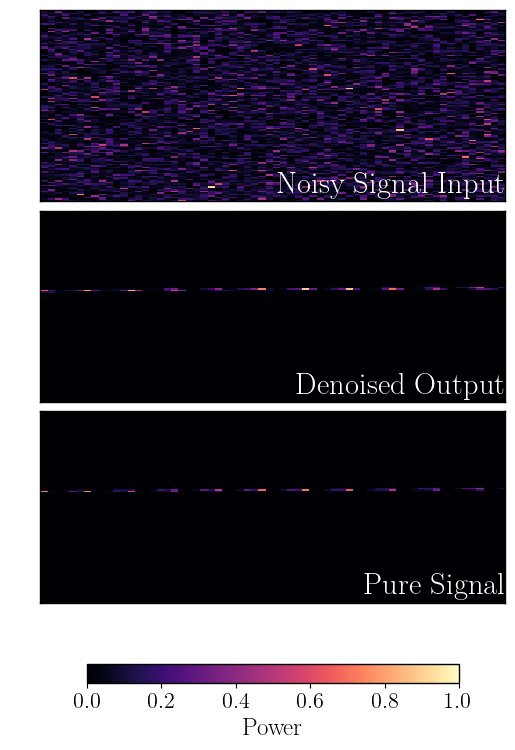

In [37]:
# Example usage
idx = 12
size = (512, 64)  # From your original code
Tsft = 14400  # From your original code
timestamps = np.arange(0, size[1]) * Tsft  # Uniform timestamps
frequency = np.arange(96, 256-32)  # Adjusted to match [96:256-32] slice
title = 'Spectrograms at 20 Hz'
subtitles = ['Noisy Signal Input', 'Denoised Output', 'Pure Signal']
fourier_data_list = [
    data[idx][96:256-32, :, :2],  # Shape: (160, 64, 2) selecting H1 real and imag
    predictions[idx].transpose(1, 2, 0)[96:256-32, :, :2],  # Adjusted to match data shape
    normalize(targets)[idx][96:256-32, :, :2]
]
fig, ax = plot_spectrograms(title, timestamps, frequency, fourier_data_list, subtitles)
fig.savefig('../result/plots/20Hz_D20_spectrogram.pdf', dpi=300, bbox_inches='tight')

In [48]:
max_train_levels = [20]
duty_factor = 0.75
# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    
    data = noise + targets
    data = normalize(data)
    data = apply_duty_factor(data, duty_factor, size)  # Apply duty factor
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)
    
    # Compute predictions
    predictions = []
    inputs = []
    ground_truth = []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
            
    predictions = np.concatenate(predictions, axis=0)

Processing Sn=20: 100%|██████████| 125/125 [00:06<00:00, 19.69it/s]
